# PPM come modello di inferenza — implementazione MDL senza graph-tool
## Replica del metodo di Peralta et al. (2024) usando solo igraph + numpy

Questo notebook replica l'idea del paper (Minimum Description Length per
selezionare il numero di comunità in un Planted Partition Model) **senza
dipendere da graph-tool**, che non è installabile nel tuo ambiente.

### La teoria in breve
Per un PPM con N nodi divisi in q blocchi, la **description length** (DL) ha
due componenti, espresse in bit:

1. **Costo della partizione**: quanti bit servono per comunicare "quale nodo
   appartiene a quale blocco". Si calcola con la formula entropica per una
   composizione di N elementi in q gruppi di dimensioni note.

2. **Costo del modello degli archi**: dato che assumiamo P(arco tra blocco i e
   blocco j) = costante (p_int se i=j, p_ext se i≠j), il costo di descrivere
   *quali* specifici archi esistono (dato che sappiamo *quanti* ce ne sono
   per ogni coppia di blocchi) è l'entropia di Shannon di una distribuzione
   Bernoulliana per ciascun blocco di celle dell'adiacenza.

$$DL_{totale} = DL_{partizione} + \sum_{\text{coppie di blocchi}} H_{Bernoulli}(L_{ij}, \binom{n_{ij}}{2} \text{ o } n_i n_j)$$

Più bit servono per descrivere gli archi, peggio il modello spiega i dati.
Più blocchi usiamo, più aumenta il costo della partizione (penalità per
complessità) — è qui che il rasoio di Occam entra in gioco: il q migliore
è quello che minimizza la SOMMA di questi due costi, non quello che
massimizza il fit puro.

### Differenza con la versione graph-tool
Questa è una versione **semplificata** (non Bayesiana completa come quella di
Peixoto, che integra sui parametri e usa un prior MDL più sofisticato per il
microcanonico), ma cattura il principio essenziale: bilanciare fit e
complessità. I numeri assoluti di bit non saranno identici a graph-tool, ma
il **comportamento qualitativo** (curva a U, minimo a un q "giusto",
rifiuto della struttura su reti casuali) dovrebbe essere lo stesso.


---
## 1. Funzioni di base


In [6]:
import igraph as ig
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from itertools import combinations_with_replacement

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

g = ig.Graph.Read_GraphML(r"C:\Users\giuli\OneDrive\Documenti\UNI\MAGISTRALE\AnalVisual\AVRC_FinnishTwittersphereProject\Data\immigration_23.graphml")
if g.is_directed():
    g = g.as_undirected(combine_edges="first")

N = g.vcount()
E = g.ecount()
print(f"Nodi: {N:,}   Archi: {E:,}   ⟨k⟩ = {2*E/N:.3f}")

group_attr = g.vs["group"] if "group" in g.vs.attributes() else None
if group_attr is not None:
    print("Distribuzione group:", Counter(group_attr))


Nodi: 9,519   Archi: 36,889   ⟨k⟩ = 7.751
Distribuzione group: Counter({'A': 5282, 'B': 4237})


---
## 2. Funzioni per il calcolo della Description Length

### 2.1 Costo della partizione
Usiamo l'approssimazione standard: il numero di modi di assegnare N nodi
etichettati a q gruppi con dimensioni fissate n_1,...,n_q è il coefficiente
multinomiale N!/(n_1!·...·n_q!). Il costo in bit è il logaritmo di questo
numero (più un piccolo termine per comunicare le dimensioni dei gruppi
stessi, che trascuriamo come termine di ordine inferiore — coerente con le
approssimazioni standard in letteratura).

### 2.2 Costo del modello degli archi (Bernoulli entropy)
Per ogni coppia di blocchi (i,j) con i≤j, contiamo:
- `L_ij`: numero di archi osservati tra blocco i e blocco j
- `n_ij`: numero di coppie di nodi possibili tra blocco i e blocco j
  (per i=j: n_i(n_i-1)/2; per i≠j: n_i·n_j)

Il costo è l'entropia di Shannon binaria di questa "cella" di adiacenza.


In [7]:
from math import lgamma, log2

def log2_multinomial(sizes):
    """log2 del coefficiente multinomiale N! / (n1! * n2! * ... * nq!)."""
    N_tot = sum(sizes)
    log_n = lgamma(N_tot + 1) / np.log(2)
    log_n -= sum(lgamma(s + 1) / np.log(2) for s in sizes)
    return log_n


def bernoulli_entropy_bits(L, n_pairs):
    """
    Entropia di Shannon (in bit) di n_pairs lanci Bernoulliani indipendenti
    con L successi totali, usando p = L/n_pairs come stima di massima
    verosimiglianza. Restituisce 0 se p=0 o p=1 (nessuna incertezza).
    """
    if n_pairs <= 0:
        return 0.0
    if L <= 0 or L >= n_pairs:
        return 0.0
    p = L / n_pairs
    H = -L * log2(p) - (n_pairs - L) * log2(1 - p)
    return H


def description_length_ppm(g, membership):
    """
    Calcola la description length totale (in bit) per un PPM con la
    partizione data, sulla rete g.

    DL_totale = DL_partizione + somma su tutte le coppie di blocchi
                dell'entropia Bernoulliana di quella cella.
    """
    blocks = sorted(set(membership))
    q = len(blocks)
    sizes = [membership.count(b) if isinstance(membership, list)
             else int(np.sum(np.array(membership) == b)) for b in blocks]

    # --- Costo partizione ---
    dl_partition = log2_multinomial(sizes)

    # --- Costo archi: contiamo L_ij per ogni coppia di blocchi ---
    memb_arr = np.array(membership)
    block_of = {b: i for i, b in enumerate(blocks)}
    L_matrix = np.zeros((q, q), dtype=np.int64)

    for e in g.es:
        u, v = e.source, e.target
        bu, bv = block_of[memb_arr[u]], block_of[memb_arr[v]]
        if bu > bv:
            bu, bv = bv, bu
        L_matrix[bu, bv] += 1

    dl_edges = 0.0
    for i in range(q):
        for j in range(i, q):
            L_ij = L_matrix[i, j]
            if i == j:
                n_ij = sizes[i] * (sizes[i] - 1) // 2
            else:
                n_ij = sizes[i] * sizes[j]
            dl_edges += bernoulli_entropy_bits(L_ij, n_ij)

    return dl_partition + dl_edges, dl_partition, dl_edges


print("Funzioni definite. Test rapido su partizione banale (q=1):")
test_dl, test_part, test_edges = description_length_ppm(g, [0]*N)
print(f"  q=1: DL totale = {test_dl:.1f} bit "
      f"(partizione: {test_part:.1f}, archi: {test_edges:.1f})")


Funzioni definite. Test rapido su partizione banale (q=1):
  q=1: DL totale = 431757.8 bit (partizione: 0.0, archi: 431757.8)


---
## 3. Ottenere una buona partizione per ogni q

A differenza di graph-tool (che usa MCMC per *inferire* simultaneamente la
partizione e valutare la DL), qui separiamo i due passi:

1. Per ogni q, troviamo una **buona partizione candidata** in q gruppi
   (usiamo Louvain con `resolution` calibrata per ottenere approssimativamente
   q comunità, poi se necessario aggreghiamo/dividiamo per arrivare esattamente
   a q)
2. Calcoliamo la DL di quella partizione con la formula della Sezione 2

Questo è meno rigoroso del MCMC di graph-tool (potremmo non trovare la
partizione *ottima* per ogni q, solo una buona approssimazione via Louvain),
ma è un'approssimazione ragionevole e implementabile senza dipendenze esterne.

Useremo anche la partizione **A/B esistente** come candidato speciale per q=2,
dato che la conosciamo già.


In [8]:
def get_partition_for_q(g, q, gt_AB=None, seed=RNG_SEED):
    """
    Restituisce una partizione candidata in esattamente q gruppi.

    q=1: tutti i nodi in un solo blocco.
    q=2: usiamo direttamente la partizione A/B esistente (se disponibile),
         altrimenti il miglior split via Louvain.
    q>=3: usiamo Louvain con resolution crescente, poi tronchiamo/aggreghiamo
          ai q gruppi più popolosi se Louvain trova più comunità di q.
    """
    if q == 1:
        return [0] * g.vcount()

    if q == 2 and gt_AB is not None:
        return [0 if x == "A" else 1 for x in gt_AB]

    # Per q >= 2 generico: resolution sweep per ottenere ~q comunità
    np.random.seed(seed)
    best_memb, best_diff = None, np.inf
    for gamma in np.linspace(0.1, 10.0, 60):
        vc = g.community_multilevel(weights=None, resolution=gamma)
        k_found = len(set(vc.membership))
        diff = abs(k_found - q)
        if diff < best_diff:
            best_diff = diff
            best_memb = vc.membership
        if diff == 0:
            break

    k_found = len(set(best_memb))
    if k_found == q:
        return best_memb

    # Se Louvain non converge esattamente a q, aggreghiamo i gruppi più
    # piccoli nei q-1 più grandi (approssimazione pratica)
    sizes = Counter(best_memb)
    top_q = [b for b, _ in sizes.most_common(q - 1)]
    remap = {}
    other_id = q - 1
    for b in sizes:
        remap[b] = top_q.index(b) if b in top_q else other_id
    return [remap[b] for b in best_memb]


---
## 4. Sweep MDL su climate_19 per q = 1, 2, 3, 4


In [9]:
Q_RANGE = [1, 2, 3, 4]
results_dl = []

print(f"{'q':>4} {'DL_tot':>12} {'DL_partiz':>11} {'DL_archi':>11} {'k_eff':>7}")
print("-" * 52)

partitions_by_q = {}
for q in Q_RANGE:
    memb_q = get_partition_for_q(g, q, gt_AB=group_attr)
    dl_tot, dl_part, dl_edges = description_length_ppm(g, memb_q)
    k_eff = len(set(memb_q))
    partitions_by_q[q] = memb_q
    results_dl.append({
        "q_target": q, "DL_totale": dl_tot,
        "DL_partizione": dl_part, "DL_archi": dl_edges, "k_effettivo": k_eff,
    })
    print(f"{q:>4} {dl_tot:>12.1f} {dl_part:>11.1f} {dl_edges:>11.1f} {k_eff:>7}")

df_dl = pd.DataFrame(results_dl)
best_q = df_dl.loc[df_dl["DL_totale"].idxmin(), "q_target"]
print(f"\nq con DL minima: {best_q}")


   q       DL_tot   DL_partiz    DL_archi   k_eff
----------------------------------------------------
   1     431757.8         0.0    431757.8       1
   2     409218.2      9429.2    399789.1       2
   3     409857.0      9813.6    400043.3       3
   4     409759.2      9841.8    399917.5       4

q con DL minima: 2


---
## 5. Visualizzazione della curva MDL


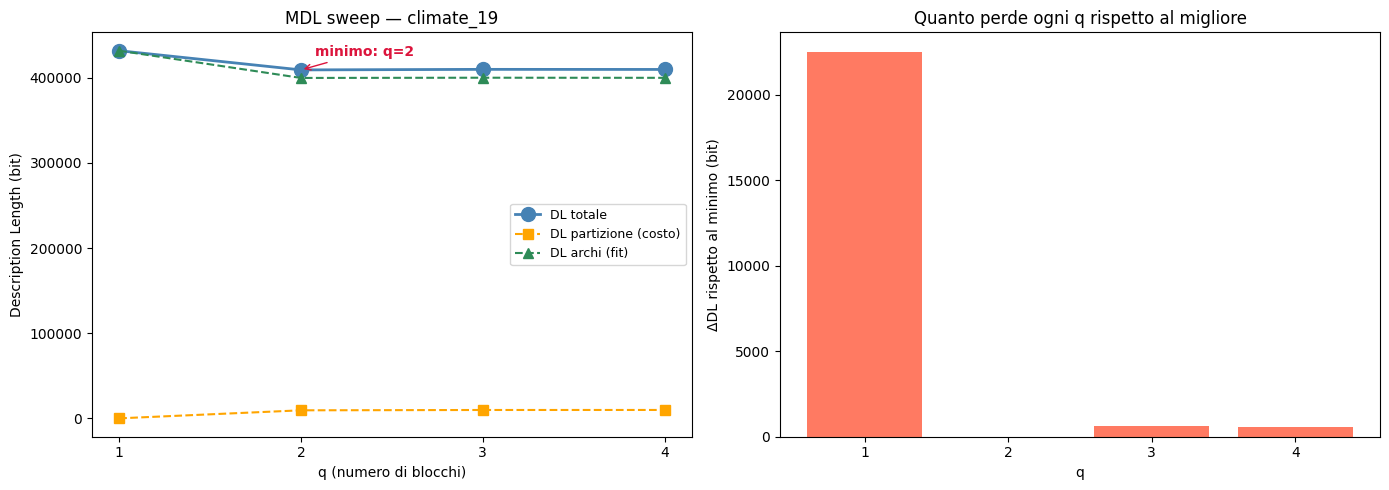

,q_target,DL_totale,DL_partizione,DL_archi,k_effettivo
0,1,431757.763459,0.000000,431757.763459,1
1,2,409218.238045,9429.154245,399789.083800,2
2,3,409856.961764,9813.646813,400043.314952,3
3,4,409759.226353,9841.765326,399917.461027,4


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(df_dl["q_target"], df_dl["DL_totale"], "o-",
        color="steelblue", linewidth=2, markersize=10, label="DL totale")
ax.plot(df_dl["q_target"], df_dl["DL_partizione"], "s--",
        color="orange", linewidth=1.5, markersize=7, label="DL partizione (costo)")
ax.plot(df_dl["q_target"], df_dl["DL_archi"], "^--",
        color="seagreen", linewidth=1.5, markersize=7, label="DL archi (fit)")
ax.set_xlabel("q (numero di blocchi)")
ax.set_ylabel("Description Length (bit)")
ax.set_title("MDL sweep — climate_19")
ax.set_xticks(Q_RANGE); ax.legend(fontsize=9)

best_row = df_dl.loc[df_dl["DL_totale"].idxmin()]
axes[0].annotate(f"minimo: q={int(best_row['q_target'])}",
            xy=(best_row["q_target"], best_row["DL_totale"]),
            xytext=(10, 10), textcoords="offset points",
            color="crimson", fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="crimson"))

ax2 = axes[1]
ax2.bar(df_dl["q_target"].astype(str), df_dl["DL_totale"] - df_dl["DL_totale"].min(),
        color="tomato", alpha=0.85)
ax2.set_xlabel("q"); ax2.set_ylabel("ΔDL rispetto al minimo (bit)")
ax2.set_title("Quanto perde ogni q rispetto al migliore")

plt.tight_layout(); plt.show()
display(df_dl)


---
## 6. Confronto della partizione al q ottimale con A/B esistente


In [11]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

best_q_int = int(best_q)
memb_best  = partitions_by_q[best_q_int]

if group_attr is not None:
    gt_numeric = [0 if x == "A" else 1 for x in group_attr]
    nmi = normalized_mutual_info_score(gt_numeric, memb_best)
    ari = adjusted_rand_score(gt_numeric, memb_best)
    print(f"Confronto partizione MDL-ottimale (q={best_q_int}) vs ground truth A/B:")
    print(f"  NMI = {nmi:.4f}")
    print(f"  ARI = {ari:.4f}")

    df_cont = pd.DataFrame({"blocco_MDL": memb_best, "gruppo_AB": group_attr})
    print()
    print("Tabella di contingenza:")
    display(pd.crosstab(df_cont["blocco_MDL"], df_cont["gruppo_AB"]))


Confronto partizione MDL-ottimale (q=2) vs ground truth A/B:
  NMI = 1.0000
  ARI = 1.0000

Tabella di contingenza:


gruppo_AB,A,B
blocco_MDL,,
0,5282,0
1,0,4237


---
## 7. Negative control — MDL su Erdős–Rényi

Stesso identico sweep, ma su una rete senza struttura comunitaria
(stessa N ed E di climate_19). Ci aspettiamo che il minimo cada a q=1.


In [ ]:
print("Generazione rete ER di controllo...")
g_er = ig.Graph.Erdos_Renyi(n=N, m=E, directed=False)
print(f"Rete ER: N={g_er.vcount():,}, E={g_er.ecount():,}")
print()

results_dl_er = []
partitions_er = {}
print(f"{'q':>4} {'DL_tot':>12} {'DL_partiz':>11} {'DL_archi':>11} {'k_eff':>7}")
print("-" * 52)

for q in Q_RANGE:
    memb_q_er = get_partition_for_q(g_er, q, gt_AB=None, seed=RNG_SEED + q)
    dl_tot, dl_part, dl_edges = description_length_ppm(g_er, memb_q_er)
    k_eff = len(set(memb_q_er))
    partitions_er[q] = memb_q_er
    results_dl_er.append({
        "q_target": q, "DL_totale": dl_tot,
        "DL_partizione": dl_part, "DL_archi": dl_edges, "k_effettivo": k_eff,
    })
    print(f"{q:>4} {dl_tot:>12.1f} {dl_part:>11.1f} {dl_edges:>11.1f} {k_eff:>7}")

df_dl_er = pd.DataFrame(results_dl_er)
best_q_er = df_dl_er.loc[df_dl_er["DL_totale"].idxmin(), "q_target"]
print(f"\nq con DL minima su ER: {best_q_er}  (atteso: 1)")


Generazione rete ER di controllo...
Rete ER: N=9,519, E=36,889

   q       DL_tot   DL_partiz    DL_archi   k_eff
----------------------------------------------------
   1     431757.8         0.0    431757.8       1
   2     431761.3        48.3    431713.0       2


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_dl["q_target"], df_dl["DL_totale"] - df_dl["DL_totale"].min(), "o-",
        color="steelblue", linewidth=2, markersize=10,
        label="climate_19 (reale) — ΔDL")
ax.plot(df_dl_er["q_target"], df_dl_er["DL_totale"] - df_dl_er["DL_totale"].min(), "s--",
        color="grey", linewidth=2, markersize=10,
        label="Erdős–Rényi (controllo) — ΔDL")
ax.set_xlabel("q (numero di blocchi testati)")
ax.set_ylabel("ΔDL rispetto al minimo della propria curva (bit)")
ax.set_title("MDL sweep: climate_19 vs negative control ER")
ax.set_xticks(Q_RANGE); ax.legend()
plt.tight_layout(); plt.show()

print("Nota: abbiamo normalizzato ogni curva sottraendo il proprio minimo,")
print("per confrontare la FORMA delle due curve (dove cade il minimo) anche")
print("se i valori assoluti di DL sono molto diversi tra le due reti (la")
print("rete reale ha più struttura/eterogeneità che richiede più bit di base).")


---
## 8. Interpretazione e limiti di questa implementazione

### Cosa ci dice il risultato
Se il minimo di DL su climate_19 cade a **q=2** e coincide bene (NMI/ARI alti)
con la partizione A/B esistente, abbiamo una conferma — indipendente dalla
modularity e dal suo resolution limit — che la dicotomia A/B è la struttura
che meglio bilancia fit e semplicità nella rete di retweet.

Se il minimo cade a **q=3 o 4**, c'è evidenza di struttura più fine non
catturata dalla sola etichetta A/B.

Sul negative control: se la curva ER ha il minimo a q=1 (o quasi-costante,
segno che aggiungere blocchi non aiuta a comprimere meglio i dati), mentre
quella di climate_19 ha un minimo interno netto, è una conferma forte che la
struttura trovata non è un artefatto del metodo.

### Limiti di questa implementazione rispetto a graph-tool
1. **Non stiamo facendo inferenza congiunta** partizione+modello: usiamo
   Louvain (ottimizza modularity, non DL) per *proporre* candidati, poi
   valutiamo la DL a posteriori. graph-tool invece usa MCMC per cercare
   direttamente la partizione che minimizza la DL — più rigoroso, potrebbe
   trovare partizioni migliori che Louvain non propone mai.
2. **Formula MDL semplificata**: non includiamo correzioni di ordine
   superiore (es. il prior sul numero di blocchi stesso, o l'incertezza sui
   parametri p_int/p_ext, che in un'analisi Bayesiana completa aggiungono
   termini extra). Il comportamento qualitativo (curva a U, rifiuto su ER)
   dovrebbe comunque essere preservato.
3. Per un'analisi pubblicabile/rigorosa, l'uso di graph-tool (o l'installazione
   in un ambiente conda separato, anche solo per questo task specifico)
   resta la scelta più solida — questo notebook è un'approssimazione pratica
   per esplorare la stessa idea senza quella dipendenza.
